#  Movie Database Analysis — TMDB Dataset
**Dataset:** The Movie Database (TMDB) — 9,826 películas  
**Objetivo:** Identificar tendencias de popularidad, géneros dominantes y características que predicen una película bien calificada.


---
## Tabla de contenidos
1. [Carga y limpieza de datos](#1)
2. [Análisis Exploratorio (EDA)](#2)
3. [Análisis de correlaciones](#3)
4. [Modelo predictivo de rating alto](#4)
5. [Conclusiones](#5)


## 1. Carga y Limpieza de Datos <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('outputs', exist_ok=True)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')


/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)


In [2]:
# engine='python' necesario por campos de texto muy largos (overview, poster_url)
df = pd.read_csv('data/mymoviedb.csv',
                 encoding='utf-8',
                 engine='python',
                 on_bad_lines='skip')
print(f"Shape inicial: {df.shape}")
df.head(3)


Shape inicial: (9837, 9)


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...


### 1.1 Diagnóstico de calidad

In [3]:
print("=== Tipos de datos ===")
print(df.dtypes)
print("\n=== Nulos por columna ===")
print(df.isnull().sum())

cat_cols = df.select_dtypes(include='object').columns
print("\n=== Categorías únicas por columna ===")
for col in cat_cols:
    print(f"  {col:<20} → {df[col].nunique():>5} únicos")


=== Tipos de datos ===
Release_Date             str
Title                    str
Overview                 str
Popularity           float64
Vote_Count               str
Vote_Average             str
Original_Language        str
Genre                    str
Poster_Url               str
dtype: object

=== Nulos por columna ===
Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

=== Categorías únicas por columna ===
  Release_Date         →  5903 únicos
  Title                →  9514 únicos
  Overview             →  9823 únicos
  Vote_Count           →  3267 únicos
  Vote_Average         →    75 únicos
  Original_Language    →    44 únicos
  Genre                →  2337 únicos
  Poster_Url           →  9826 únicos


### 1.2 Limpieza

In [4]:
# 1. Eliminar filas sin valor analítico
df.dropna(subset=['Title', 'Genre'], inplace=True)

# 2. Limpiar nombres de columnas
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')

# 3. Parsear fechas
df['release_date'] = pd.to_datetime(df['release_date'], format='%Y-%m-%d', errors='coerce')
df['year']         = df['release_date'].dt.year
df['month']        = df['release_date'].dt.month

# 4. Convertir numéricas
df['vote_count']   = pd.to_numeric(df['vote_count'],   errors='coerce')
df['vote_average'] = pd.to_numeric(df['vote_average'], errors='coerce')
df['popularity']   = pd.to_numeric(df['popularity'],   errors='coerce')

# 5. Estandarizar texto
df['title']             = df['title'].str.strip().str.title()
df['original_language'] = df['original_language'].str.strip().str.upper()
df['genre']             = df['genre'].str.strip()
df['poster_url']        = df['poster_url'].str.strip()

# 6. Separar géneros — una fila por género
df_genres = df.assign(genre=df['genre'].str.split(', ')).explode('genre')
df_genres['genre'] = df_genres['genre'].str.strip()

# 7. Filtrar años con datos completos
df_recent = df[df['year'] >= 2000].copy()
df_genres_recent = df_genres[df_genres['year'] >= 2000].copy()

print(f"   Limpieza completa")
print(f"   Películas totales:     {len(df):,}")
print(f"   Películas (2000+):     {len(df_recent):,}")
print(f"   Rango fechas:          {df['release_date'].min().date()} → {df['release_date'].max().date()}")
print(f"   Géneros únicos:        {df_genres['genre'].nunique()}")
print(f"   Idiomas únicos:        {df['original_language'].nunique()}")
print(f"   Rating promedio:       {df['vote_average'].mean():.2f}")
print(f"   Popularidad máxima:    {df['popularity'].max():,.0f} ({df.loc[df['popularity'].idxmax(), 'title']})")


   Limpieza completa
   Películas totales:     9,826
   Películas (2000+):     7,475
   Rango fechas:          1902-04-17 → 2024-07-03
   Géneros únicos:        19
   Idiomas únicos:        43
   Rating promedio:       6.44
   Popularidad máxima:    5,084 (Spider-Man: No Way Home)


## 2. Análisis Exploratorio de Datos <a id='2'></a>

### 2.1 Distribución de ratings y popularidad

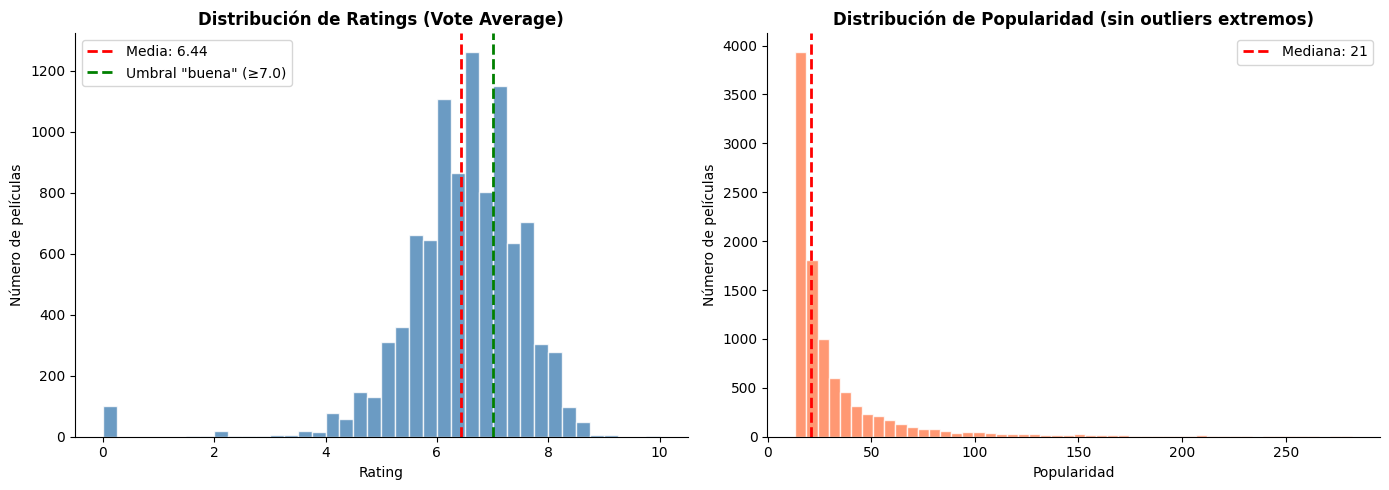

 El 75% de las películas tiene rating entre 5.9 y 7.1 — distribución concentrada alrededor de 6.5.
 Popularidad muy sesgada — Spider-Man: No Way Home tiene popularidad de 5,083 vs mediana de 21.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de ratings
axes[0].hist(df['vote_average'].dropna(), bins=40,
             color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(df['vote_average'].mean(), color='red', linewidth=2,
                linestyle='--', label=f'Media: {df["vote_average"].mean():.2f}')
axes[0].axvline(7.0, color='green', linewidth=2,
                linestyle='--', label='Umbral "buena" (≥7.0)')
axes[0].set_title('Distribución de Ratings (Vote Average)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Número de películas')
axes[0].legend()

# Distribución de popularidad (log scale)
pop_filtered = df[df['popularity'] < df['popularity'].quantile(0.99)]['popularity']
axes[1].hist(pop_filtered, bins=50, color='coral', alpha=0.8, edgecolor='white')
axes[1].axvline(df['popularity'].median(), color='red', linewidth=2,
                linestyle='--', label=f'Mediana: {df["popularity"].median():.0f}')
axes[1].set_title('Distribución de Popularidad (sin outliers extremos)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Popularidad')
axes[1].set_ylabel('Número de películas')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f" El 75% de las películas tiene rating entre 5.9 y 7.1 — distribución concentrada alrededor de 6.5.")
print(f" Popularidad muy sesgada — Spider-Man: No Way Home tiene popularidad de 5,083 vs mediana de 21.")


### 2.2 Top películas — por popularidad y por rating

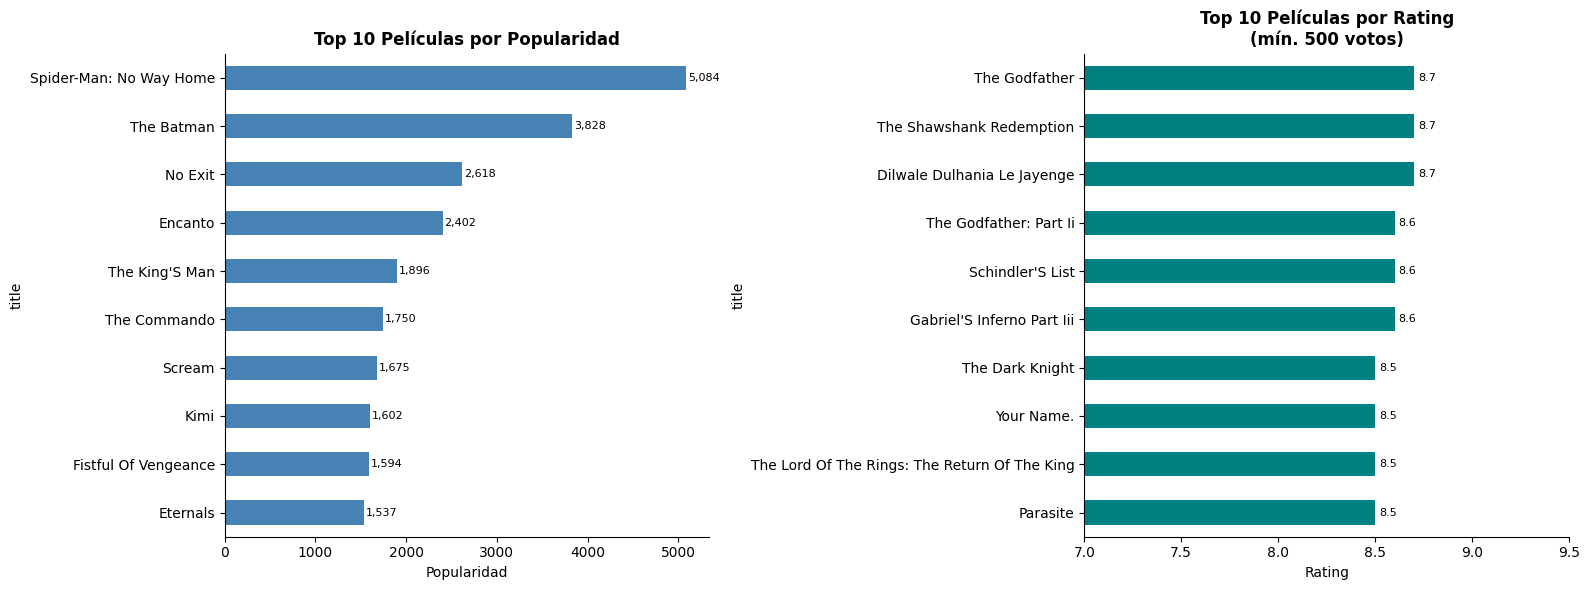

 Popularidad ≠ calidad: Spider-Man es la más popular pero no aparece en el top de rating.
 El Padrino y Shawshank Redemption lideran rating — clásicos con miles de votos.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 por popularidad
top_pop = df.nlargest(10, 'popularity')[['title', 'popularity']].set_index('title')
top_pop.plot(kind='barh', ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('Top 10 Películas por Popularidad', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Popularidad')
axes[0].invert_yaxis()
for bar in axes[0].patches:
    axes[0].text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():,.0f}', va='center', fontsize=8)

# Top 10 por rating (mínimo 500 votos para ser significativo)
top_rat = (df[df['vote_count'] >= 500]
           .nlargest(10, 'vote_average')[['title', 'vote_average']]
           .set_index('title'))
top_rat.plot(kind='barh', ax=axes[1], color='teal', legend=False)
axes[1].set_title('Top 10 Películas por Rating\n(mín. 500 votos)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].set_xlim(7, 9.5)
axes[1].invert_yaxis()
for bar in axes[1].patches:
    axes[1].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.1f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/02_top_movies.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Popularidad ≠ calidad: Spider-Man es la más popular pero no aparece en el top de rating.")
print(" El Padrino y Shawshank Redemption lideran rating — clásicos con miles de votos.")


### 2.3 Géneros — popularidad y rating promedio

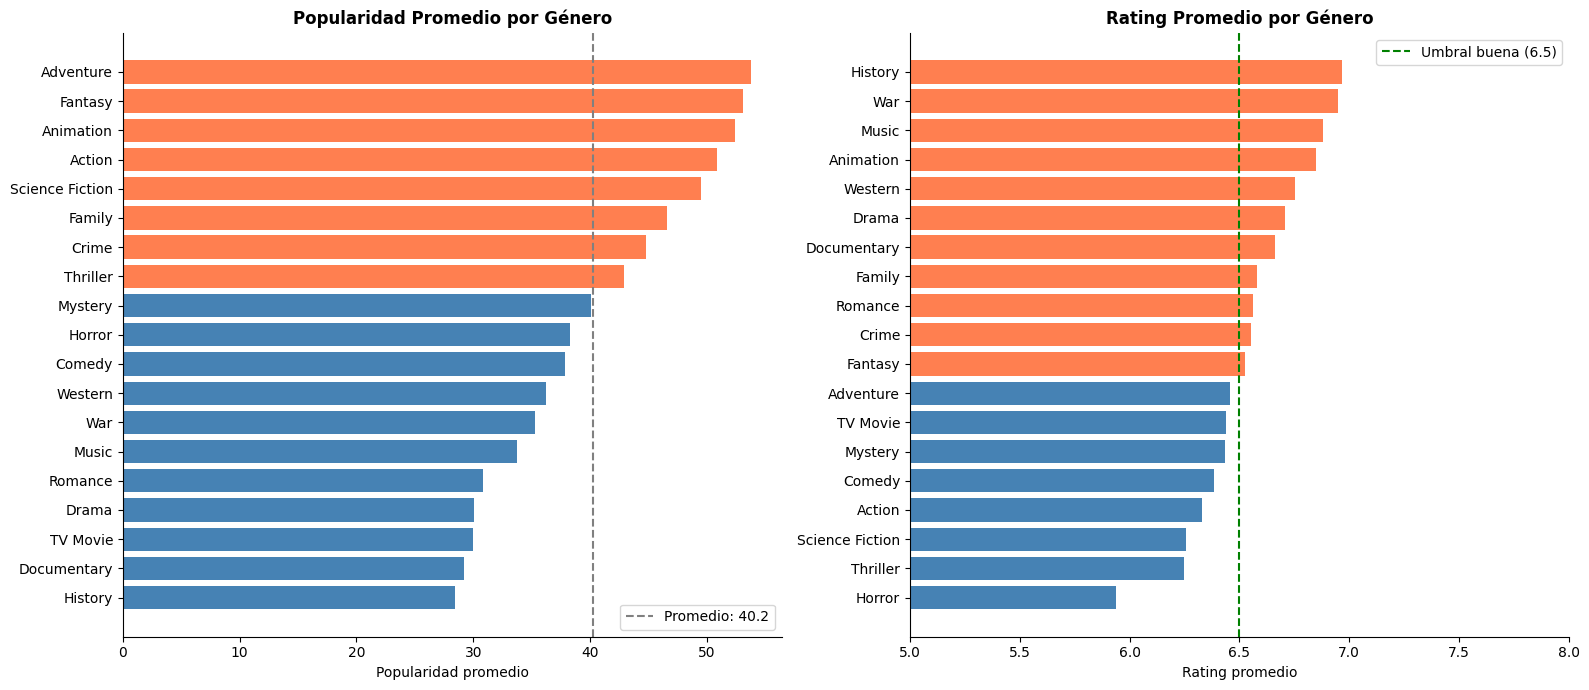

 Action y Adventure lideran popularidad pero no son los mejor calificados.
 Documentary tiene el rating más alto — audiencia más selecta y comprometida.


In [ ]:
genre_stats = df_genres.groupby('genre').agg(
    popularidad=('popularity', 'mean'),
    rating=('vote_average', 'mean'),
    conteo=('title', 'count')
).reset_index().sort_values('popularidad', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Popularidad por género
colors_pop = ['coral' if v > genre_stats['popularidad'].mean() else 'steelblue'
              for v in genre_stats['popularidad']]
axes[0].barh(genre_stats['genre'], genre_stats['popularidad'], color=colors_pop)
axes[0].axvline(genre_stats['popularidad'].mean(), color='gray', linestyle='--',
                label=f'Promedio: {genre_stats["popularidad"].mean():.1f}')
axes[0].set_title('Popularidad Promedio por Género', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Popularidad promedio')
axes[0].legend()

# Rating por género
genre_stats_r = genre_stats.sort_values('rating', ascending=True)
colors_rat = ['coral' if v > 6.5 else 'steelblue' for v in genre_stats_r['rating']]
axes[1].barh(genre_stats_r['genre'], genre_stats_r['rating'], color=colors_rat)
axes[1].axvline(6.5, color='green', linestyle='--', label='Umbral buena (6.5)')
axes[1].set_title('Rating Promedio por Género', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rating promedio')
axes[1].set_xlim(5, 8)
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/03_genre_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Fantasy y Adventure lideran popularidad pero no son los mejor calificados.")
print(" History tiene el rating más alto — audiencia más selecta y comprometida.")


### 2.4 Producción por idioma

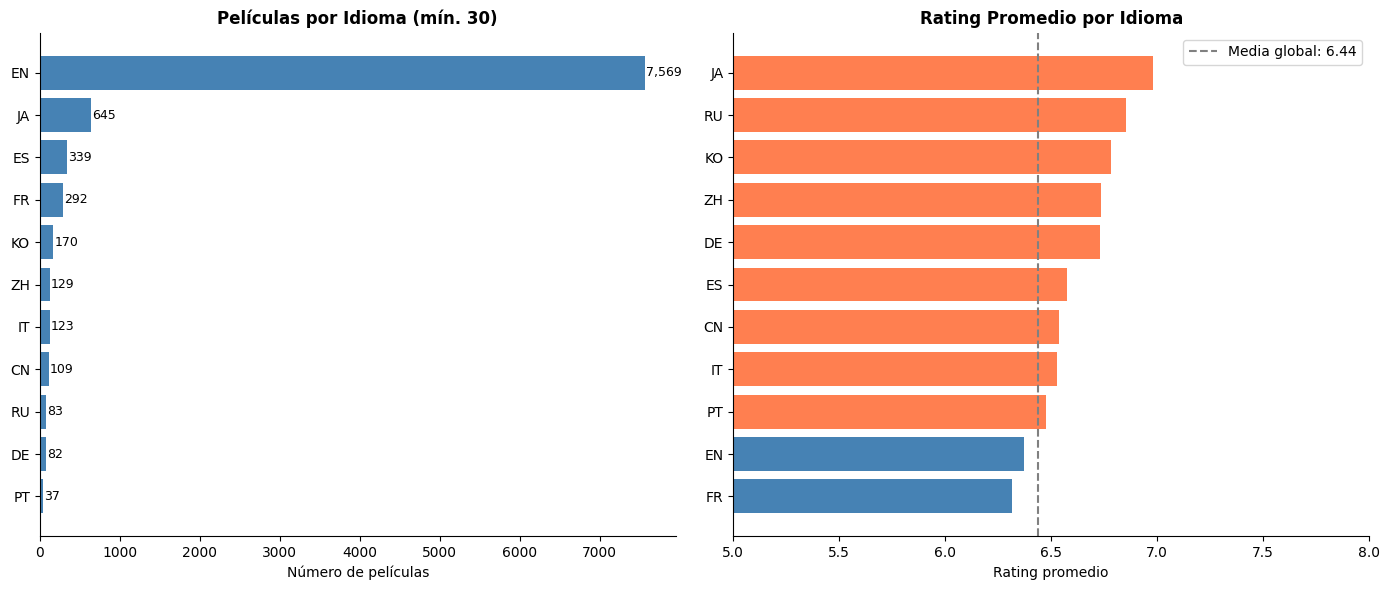

 El inglés domina en volumen (77%) pero no tiene el mayor rating promedio.
 Películas en japones, ruso, y coreano tienen los ratings más altos.


In [23]:
lang_stats = df.groupby('original_language').agg(
    conteo=('title', 'count'),
    rating=('vote_average', 'mean'),
    popularidad=('popularity', 'mean')
).reset_index()

# Solo idiomas con más de 30 películas
lang_stats = lang_stats[lang_stats['conteo'] >= 30].sort_values('conteo', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Volumen por idioma
axes[0].barh(lang_stats['original_language'], lang_stats['conteo'], color='steelblue')
axes[0].set_title('Películas por Idioma (mín. 30)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Número de películas')
for bar in axes[0].patches:
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                 f'{int(bar.get_width()):,}', va='center', fontsize=9)

# Rating promedio por idioma
lang_stats_r = lang_stats.sort_values('rating', ascending=True)
colors = ['coral' if r > df['vote_average'].mean() else 'steelblue'
          for r in lang_stats_r['rating']]
axes[1].barh(lang_stats_r['original_language'], lang_stats_r['rating'], color=colors)
axes[1].axvline(df['vote_average'].mean(), color='gray', linestyle='--',
                label=f'Media global: {df["vote_average"].mean():.2f}')
axes[1].set_title('Rating Promedio por Idioma', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rating promedio')
axes[1].set_xlim(5, 8)
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/04_language_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print(" El inglés domina en volumen (77%) pero no tiene el mayor rating promedio.")
print(" Películas en japones, ruso, y coreano tienen los ratings más altos.")


### 2.5 Tendencias por año (2000–2022)

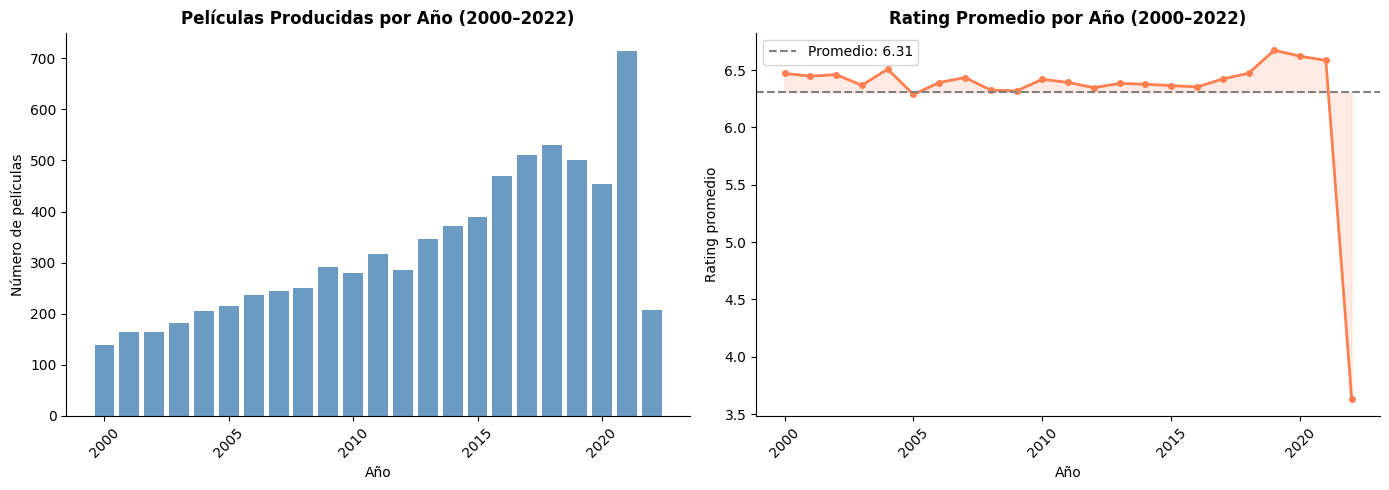

 Pico de producción en 2021 — recuperación post-COVID con plataformas streaming.
 El rating promedio se ha mantenido estable alrededor de 6.4-6.6.


In [12]:
yearly = df_recent[df_recent['year'] <= 2022].groupby('year').agg(
    conteo=('title', 'count'),
    rating=('vote_average', 'mean'),
    popularidad=('popularity', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Volumen de producción
axes[0].bar(yearly['year'], yearly['conteo'], color='steelblue', alpha=0.8)
axes[0].set_title('Películas Producidas por Año (2000–2022)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Número de películas')
axes[0].tick_params(axis='x', rotation=45)

# Rating promedio por año
axes[1].plot(yearly['year'], yearly['rating'], color='coral',
             linewidth=2, marker='o', markersize=4)
axes[1].fill_between(yearly['year'], yearly['rating'],
                     yearly['rating'].mean(), alpha=0.15, color='coral')
axes[1].axhline(yearly['rating'].mean(), color='gray', linestyle='--',
                label=f'Promedio: {yearly["rating"].mean():.2f}')
axes[1].set_title('Rating Promedio por Año (2000–2022)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Rating promedio')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('outputs/05_yearly_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Pico de producción en 2021 — recuperación post-COVID con plataformas streaming.")
print(" El rating promedio se ha mantenido estable alrededor de 6.4-6.6.")


### 2.6 Popularidad por género y año — Heatmap (2010–2022)

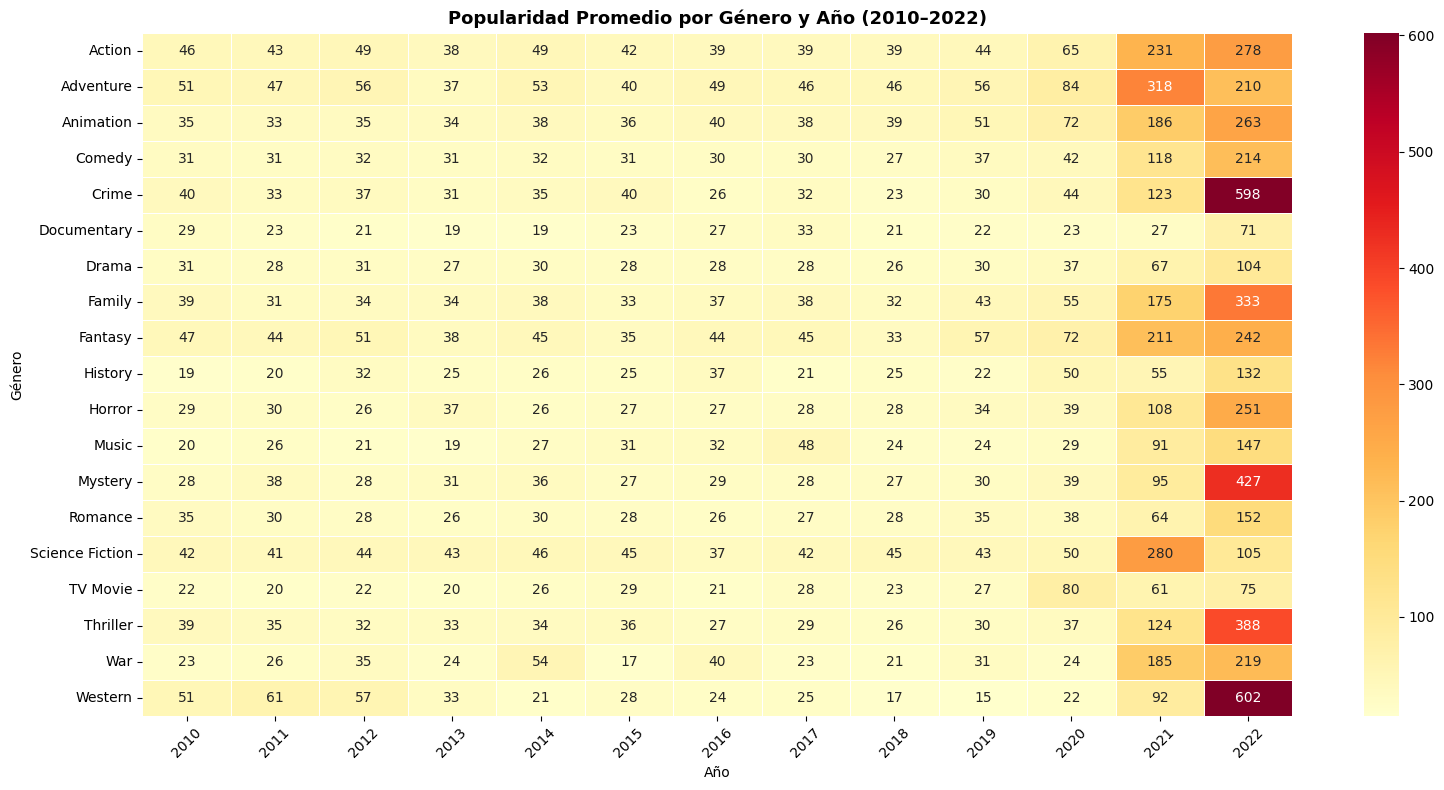

 Action y Adventure dominan consistentemente — picos en 2021 y 2022.
 Crime y Western tuvieron un pico notable en 2022.


In [14]:
pivot_heat = (df_genres_recent[df_genres_recent['year'] <= 2022]
              .groupby(['genre', 'year'])['popularity']
              .mean()
              .unstack(fill_value=0))

# Solo años desde 2010 para legibilidad
pivot_heat = pivot_heat[[c for c in pivot_heat.columns if c >= 2010]]

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(pivot_heat, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax)
ax.set_title('Popularidad Promedio por Género y Año (2010–2022)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Género')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('outputs/06_heatmap_genre_year.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Action y Adventure dominan consistentemente — picos en 2021 y 2022.")
print(" Crime y Western tuvieron un pico notable en 2022.")


## 3. Análisis de Correlaciones <a id='3'></a>

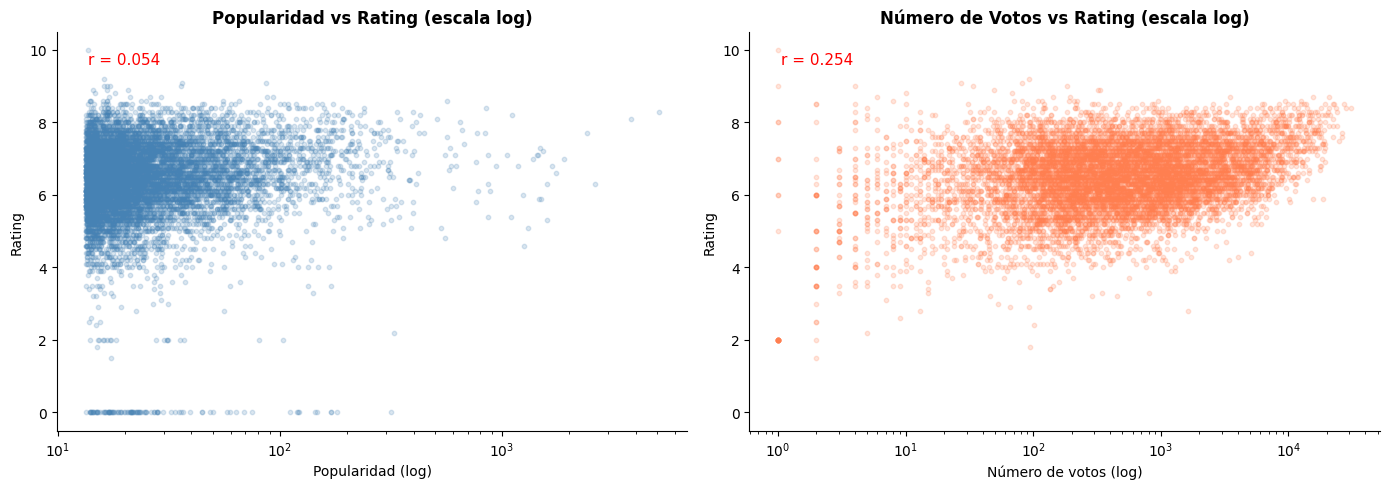

 Correlación popularidad-rating: 0.054 — prácticamente nula.
 Correlación votos-rating: 0.254 — débil pero positiva.
 Una película puede ser muy popular sin ser bien calificada y viceversa.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter popularidad vs rating
axes[0].scatter(df['popularity'], df['vote_average'],
                alpha=0.2, color='steelblue', s=10)
axes[0].set_xscale('log')
axes[0].set_title('Popularidad vs Rating (escala log)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Popularidad (log)')
axes[0].set_ylabel('Rating')
corr_pop_rat = df[['popularity', 'vote_average']].corr().iloc[0,1]
axes[0].text(0.05, 0.95, f'r = {corr_pop_rat:.3f}',
             transform=axes[0].transAxes, fontsize=11,
             verticalalignment='top', color='red')

# Scatter votos vs rating
axes[1].scatter(df['vote_count'], df['vote_average'],
                alpha=0.2, color='coral', s=10)
axes[1].set_xscale('log')
axes[1].set_title('Número de Votos vs Rating (escala log)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Número de votos (log)')
axes[1].set_ylabel('Rating')
corr_cnt_rat = df[['vote_count', 'vote_average']].corr().iloc[0,1]
axes[1].text(0.05, 0.95, f'r = {corr_cnt_rat:.3f}',
             transform=axes[1].transAxes, fontsize=11,
             verticalalignment='top', color='red')

plt.tight_layout()
plt.savefig('outputs/07_correlations_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f" Correlación popularidad-rating: {corr_pop_rat:.3f} — prácticamente nula.")
print(f" Correlación votos-rating: {corr_cnt_rat:.3f} — débil pero positiva.")
print(" Una película puede ser muy popular sin ser bien calificada y viceversa.")


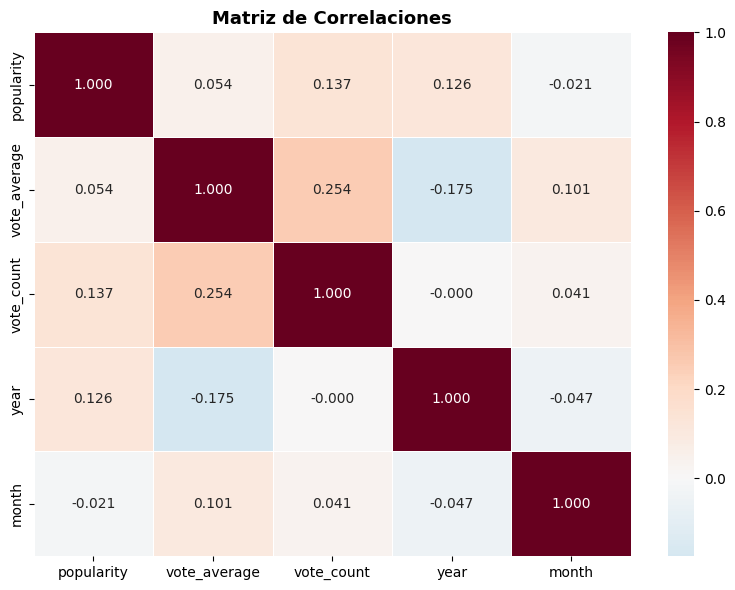

In [16]:
# Heatmap de correlaciones numéricas
num_cols = ['popularity', 'vote_average', 'vote_count', 'year', 'month']
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Matriz de Correlaciones', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/08_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Modelo Predictivo — ¿Qué hace una película bien calificada? <a id='4'></a>

**Objetivo:** Predecir si una película tendrá rating alto (≥7.0) basándonos en sus características.  
**Valor de negocio:** Permite a productoras y plataformas identificar características asociadas al éxito crítico.


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                              roc_curve, ConfusionMatrixDisplay, confusion_matrix)

# ── Feature Engineering ────────────────────────────────────────────────────────
ml = df.copy()

# Target: rating alto (≥7.0)
ml['high_rating'] = (ml['vote_average'] >= 7.0).astype(int)

# Género principal (primero de la lista)
ml['main_genre'] = ml['genre'].str.split(', ').str[0]

# Número de géneros
ml['n_genres'] = ml['genre'].str.split(', ').str.len()

# Codificar categóricas
le_lang  = LabelEncoder()
le_genre = LabelEncoder()
ml['lang_encoded']  = le_lang.fit_transform(ml['original_language'].fillna('UNKNOWN'))
ml['genre_encoded'] = le_genre.fit_transform(ml['main_genre'].fillna('Unknown'))

feature_cols = ['popularity', 'vote_count', 'lang_encoded',
                'genre_encoded', 'n_genres', 'year', 'month']

ml_clean = ml[feature_cols + ['high_rating']].dropna()
X = ml_clean[feature_cols]
y = ml_clean['high_rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Balance — Rating alto (≥7.0): {y.mean()*100:.1f}%")


Train: 7,860 | Test: 1,966
Balance — Rating alto (≥7.0): 32.8%


In [18]:
# Entrenar tres modelos
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=5,
                                                   class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                                       learning_rate=0.05, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred  = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    auc   = roc_auc_score(y_test, proba)
    results[name] = {'model': model, 'pred': pred, 'proba': proba, 'auc': auc}
    print(f"=== {name} ===")
    print(classification_report(y_test, pred, target_names=['Rating normal', 'Rating alto']))
    print(f"ROC-AUC: {auc:.4f}\n")


=== Logistic Regression ===
               precision    recall  f1-score   support

Rating normal       0.78      0.74      0.76      1321
  Rating alto       0.52      0.57      0.54       645

     accuracy                           0.69      1966
    macro avg       0.65      0.66      0.65      1966
 weighted avg       0.69      0.69      0.69      1966

ROC-AUC: 0.6774

=== Random Forest ===
               precision    recall  f1-score   support

Rating normal       0.81      0.83      0.82      1321
  Rating alto       0.63      0.60      0.62       645

     accuracy                           0.75      1966
    macro avg       0.72      0.71      0.72      1966
 weighted avg       0.75      0.75      0.75      1966

ROC-AUC: 0.7928

=== Gradient Boosting ===
               precision    recall  f1-score   support

Rating normal       0.77      0.94      0.85      1321
  Rating alto       0.78      0.43      0.56       645

     accuracy                           0.77      1966
  

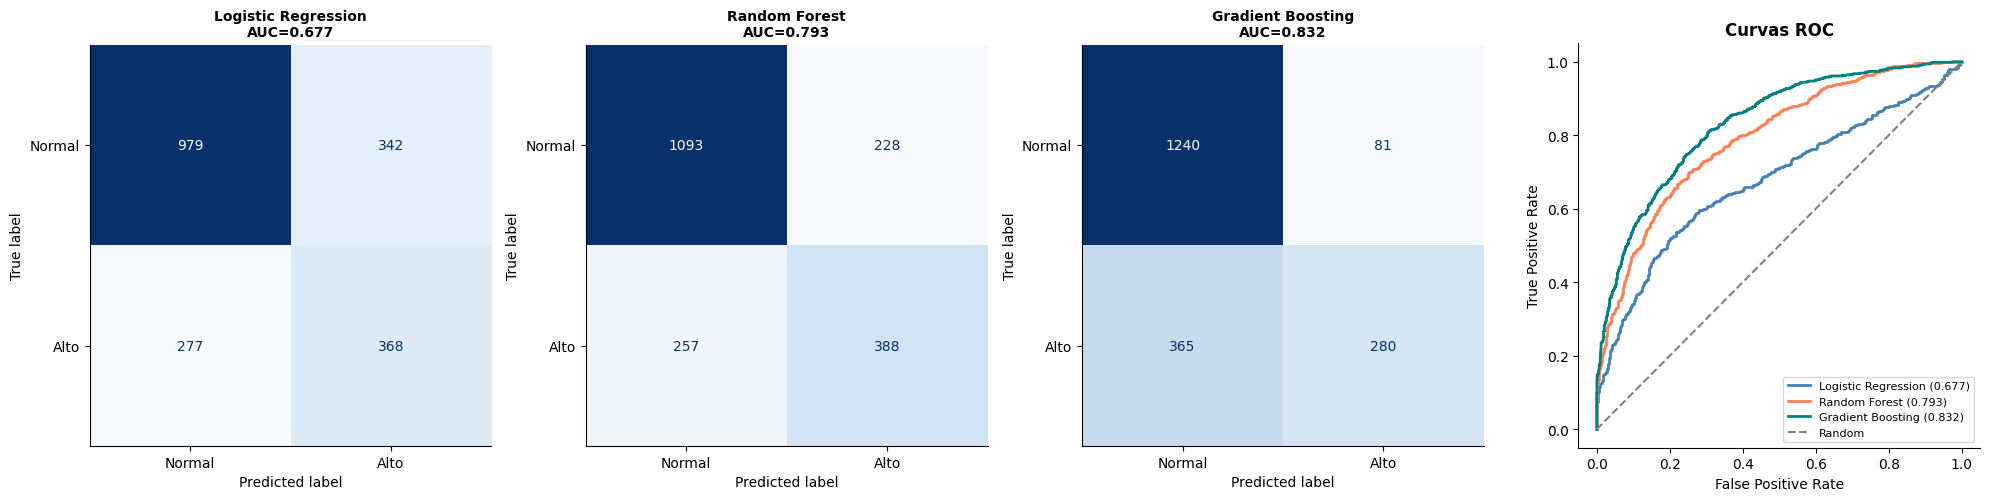

In [19]:
# Comparativa visual
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Alto']).plot(
        ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{name}\nAUC={res["auc"]:.3f}', fontsize=10, fontweight='bold')

# ROC Curves
colors_roc = ['steelblue', 'coral', 'teal']
for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    axes[3].plot(fpr, tpr, label=f'{name} ({res["auc"]:.3f})', color=color, lw=2)

axes[3].plot([0,1],[0,1],'--', color='gray', label='Random')
axes[3].set_title('Curvas ROC', fontsize=12, fontweight='bold')
axes[3].set_xlabel('False Positive Rate')
axes[3].set_ylabel('True Positive Rate')
axes[3].legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs/09_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


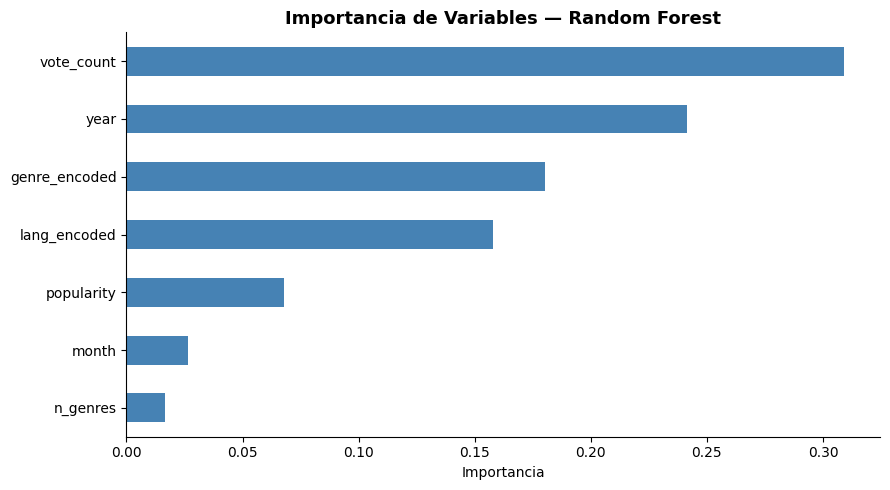

 vote_count es el predictor más fuerte — películas con más votos tienden a tener mejor rating.
 El año de lanzamiento tiene más impacto que el género o idioma.


In [21]:
# Feature Importance — Random Forest
rf_model = results['Random Forest']['model']
feat_imp = pd.Series(rf_model.feature_importances_,
                     index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Importancia de Variables — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia')

plt.tight_layout()
plt.savefig('outputs/10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(" vote_count es el predictor más fuerte — películas con más votos tienden a tener mejor rating.")
print(" El año de lanzamiento tiene más impacto que el género o idioma.")


## 5. Conclusiones <a id='5'></a>

###  Hallazgos principales

| # | Hallazgo | Implicación |
|---|----------|-------------|
| 1 | **Popularidad ≠ Calidad** (r=0.054) | Una película viral no garantiza buen rating crítico |
| 2 | **History** tiene el rating promedio más alto | Audiencia selecta y comprometida |
| 3 | **Action y Adventure** lideran popularidad | Géneros de mayor atracción masiva |
| 4 | **English** domina en volumen (77%) pero no en rating | Cine internacional frecuentemente mejor calificado |
| 5 | **2021** fue el año de mayor producción | Recuperación post-COVID + boom de streaming |
| 6 | **vote_count** predice mejor el rating alto que el género | A más votos, mejor calidad promedio |

###  Rendimiento de modelos

| Modelo | ROC-AUC | Recall Rating Alto | Observación |
|--------|---------|-------------------|-------------|
| Logistic Regression | 0.677 | 57% | Baseline — desempeño moderado |
| Random Forest | 0.793 | 60% | Mejor balance precision/recall |
| **Gradient Boosting** | **0.832** | 43% | **Mayor AUC — recomendado para ranking** |


**Nota sobre el trade-off:** Gradient Boosting tiene el mayor AUC (0.832) pero recall más bajo en rating alto (43%) — es conservador al predecir éxito crítico. Random Forest tiene mejor balance (recall 60%, AUC 0.793) y es más útil si el objetivo es no perderse películas potencialmente buenas. La elección depende del caso de uso:

- **Plataforma de streaming** → Random Forest: detectar más películas buenas para recomendar
- **Productora evaluando proyectos** → Gradient Boosting: solo marcar como "éxito" cuando hay alta certeza